In [34]:
from pathlib import Path
import yaml
import pandas as pd
from pathlib import Path
import sqlite3
from tqdm import tqdm

datasets_base_path = Path('datasets')
datasets_base_path.mkdir(exist_ok=True)

con = sqlite3.connect('omop.db')
cur = con.cursor()

dfs = []

with open(Path('sql_commands.yaml'), 'r') as f:
    sql_commands = yaml.safe_load(f)

for command_name in tqdm(sql_commands.keys()):
    sql_prompt = sql_commands[command_name]['sql']
    sql_prompt_df = pd.read_sql(sql_prompt, con)
    sql_prompt_df['prompt'] = sql_prompt_df['concept_name']
    sql_prompt_df['completion'] = sql_prompt_df['vocabulary_id'] + ' ' + sql_prompt_df['concept_code']

    relevant_cols = [
        'concept_id',
        'prompt',
        'completion',
    ]

    sql_prompt_df[relevant_cols].to_csv(datasets_base_path / f'{command_name}.csv', index=False)
    dfs.append(sql_prompt_df[relevant_cols])
    print(command_name, sql_prompt_df[relevant_cols].shape)


 25%|██▌       | 1/4 [00:01<00:04,  1.38s/it]

std_concept_to_std_vocab_code (619382, 3)


 50%|█████     | 2/4 [00:16<00:18,  9.17s/it]

std_concept_synonym_to_std_vocab_code (1711945, 3)


 75%|███████▌  | 3/4 [00:19<00:06,  6.50s/it]

non_std_concept_to_std_vocab_code (41532, 3)


100%|██████████| 4/4 [00:32<00:00,  8.17s/it]

non_std_concept_synonym_to_std_vocab_code (92166, 3)


In [80]:
concat_df = pd.concat(dfs)
concat_df[concat_df['completion']=='SNOMED 416098002']

,concept_id,prompt,completion
424130,439224,Allergy to drug,SNOMED 416098002
972201,439224,Allergy to drug (finding),SNOMED 416098002
972202,439224,Drug allergy,SNOMED 416098002
972203,439224,Medication allergy,SNOMED 416098002
972204,439224,Medicine allergy,SNOMED 416098002
...,...,...,...
46648,46284856,Allergy to aliskiren (finding),SNOMED 416098002
46649,46287025,Allergy to ticagrelor (finding),SNOMED 416098002
46650,46287025,Ticagrelor allergy,SNOMED 416098002
46678,46286393,Allergy to rivaroxaban (finding),SNOMED 416098002


array([[<Axes: title={'center': 'concept_id'}>]], dtype=object)

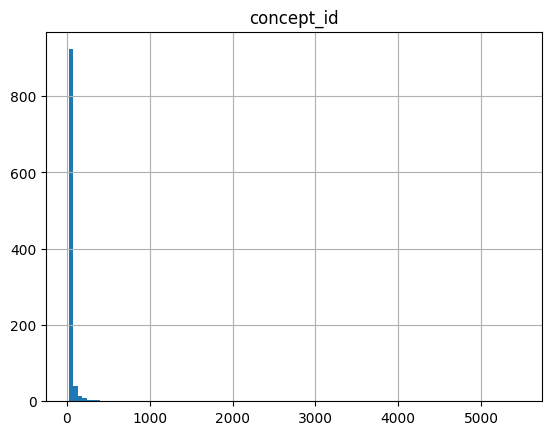

In [45]:
summ_df = concat_df.groupby('completion').count().sort_values('concept_id', ascending=False)
summ_df[0:1000].hist(column='concept_id', bins=100)

In [85]:
concat_df['prompt'].duplicated().sum()

np.int64(92605)

In [1]:
import pandas as pd
from pathlib import Path
import sqlite3

datasets_base_path = Path('datasets')
datasets_base_path.mkdir(exist_ok=True)

con = sqlite3.connect('omop.db')
cur = con.cursor()

In [2]:
cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cur.fetchall()
print(tables)

[('concept',), ('concept_ancestor',), ('concept_class',), ('concept_relationship',), ('concept_synonym',), ('domain',), ('drug_strength',), ('relationship',), ('source_to_concept_map',), ('vocabulary',)]


In [20]:
# Collect concept_id + concept_name from standard vocabularies
sql_prompt = f"""
SELECT 
    c.concept_id,
    c.concept_name,
    c.vocabulary_id,
    c.concept_code
FROM concept c
WHERE standard_concept = 'S'
    AND vocabulary_id IN ('SNOMED', 'RxNorm', 'LOINC');
"""
standard_concept_df = pd.read_sql(sql_prompt, con)
standard_concept_df

,concept_id,concept_name,vocabulary_id,concept_code
0,42538812,Somatic hallucination,SNOMED,762620006
1,4084170,Non-allergic anaphylaxis caused by whole blood,SNOMED,241944009
2,4085530,Unformed visual hallucinations,SNOMED,247733004
3,4085038,Formed visual hallucinations,SNOMED,247734005
4,4085531,Scenic visual hallucinations,SNOMED,247735006
...,...,...,...,...
619377,1261320,Cardiology,LOINC,LA33928-5
619378,1261321,Ability to rise in a single movement_no loss o...,LOINC,LA33951-7
619379,1261322,"Multiple attempts, but successful",LOINC,LA33953-3
619380,1261323,SeptiScore Range,LOINC,LA33769-3


In [21]:
standard_concept_df['prompt'] = standard_concept_df['concept_name']
standard_concept_df['completion'] = standard_concept_df['vocabulary_id'] + ' ' + standard_concept_df['concept_code']

relevant_cols = [
    'concept_id',
    'prompt',
    'completion',
]

standard_concept_df[relevant_cols].to_csv(datasets_base_path / 'standard_concepts_to_codes.csv', index=False)
standard_concept_df[relevant_cols]

,concept_id,prompt,completion
0,42538812,Somatic hallucination,SNOMED 762620006
1,4084170,Non-allergic anaphylaxis caused by whole blood,SNOMED 241944009
2,4085530,Unformed visual hallucinations,SNOMED 247733004
3,4085038,Formed visual hallucinations,SNOMED 247734005
4,4085531,Scenic visual hallucinations,SNOMED 247735006
...,...,...,...
619377,1261320,Cardiology,LOINC LA33928-5
619378,1261321,Ability to rise in a single movement_no loss o...,LOINC LA33951-7
619379,1261322,"Multiple attempts, but successful",LOINC LA33953-3
619380,1261323,SeptiScore Range,LOINC LA33769-3


In [22]:
sql_prompt = f"""
SELECT *
FROM concept_relationship
"""
concept_synonyms_df = pd.read_sql(sql_prompt, con)
concept_synonyms_df

,concept_id_1,concept_id_2,relationship_id,valid_start_date,valid_end_date,invalid_reason
0,45769145,434972,Is a,20150131,20991231,None
1,45769145,4064671,Has asso morph,20170401,20991231,None
2,45769145,4204670,Has pathology,20190131,20991231,None
3,45769145,45769145,Mapped from,20150131,20991231,None
4,45769145,45769145,Maps to,20150131,20991231,None
...,...,...,...,...,...,...
12672739,45769144,45764290,Subsumes,20150131,20991231,None
12672740,45769144,45769144,Mapped from,20150131,20991231,None
12672741,45769144,45769144,Maps to,20150131,20991231,None
12672742,45769144,45770984,Subsumes,20150131,20991231,None


In [15]:
# Collect concept_id + concept_name from standard vocabularies
sql_prompt = f"""
SELECT 
    c.concept_id, 
    c.concept_name
FROM concept c
WHERE standard_concept = 'S'
    AND vocabulary_id IN ('SNOMED', 'RxNorm', 'LOINC');
"""
standard_concept_df = pd.read_sql(sql_prompt, con)

# Join with synonyms
sql_prompt = f"""
SELECT 
    c1.concept_id AS concept_id, 
    c2.concept_synonym_name AS concept_name,
    c1.vocabulary_id,
    c1.concept_code
FROM concept c1
INNER JOIN concept_synonym c2 ON c1.concept_id = c2.concept_id
WHERE c1.standard_concept = 'S'
    AND c1.vocabulary_id IN ('SNOMED', 'RxNorm', 'LOINC');
"""
standard_concept_synonyms_df = pd.read_sql(sql_prompt, con)

In [16]:
standard_concept_synonyms_df

,concept_id,concept_name,vocabulary_id,concept_code
0,42538812,Somatic hallucination (finding),SNOMED,762620006
1,42538812,alucinación somática,SNOMED,762620006
2,42538812,alucinación somática (hallazgo),SNOMED,762620006
3,4084170,Non-allergic anaphylaxis caused by whole blood...,SNOMED,241944009
4,4084170,Whole blood-induced anaphylactoid reaction,SNOMED,241944009
...,...,...,...,...
1711940,1988313,Admin info; Centers for Medicare and Medicaid ...,LOINC,99132-3
1711941,1259466,ABS; Aby; Acid Fast; Acid Fast Bacilli; Acid f...,LOINC,104432-0
1711942,1259466,M.leprae anti-PGL-1 Ab Titr Ser,LOINC,104432-0
1711943,1259466,"Mycobacterium leprae anti-PGL-1 antibody, Blood",LOINC,104432-0


In [17]:
standard_concept_synonyms_df['prompt'] = standard_concept_synonyms_df['concept_name']
standard_concept_synonyms_df['completion'] = standard_concept_synonyms_df['vocabulary_id'] + ' ' + standard_concept_synonyms_df['concept_code']

relevant_cols = [
    'concept_id',
    'prompt',
    'completion',
]

standard_concept_synonyms_df[relevant_cols].to_csv(datasets_base_path / 'synonyms_to_codes.csv', index=False)
standard_concept_synonyms_df[relevant_cols]

,concept_id,prompt,completion
0,42538812,Somatic hallucination (finding),SNOMED 762620006
1,42538812,alucinación somática,SNOMED 762620006
2,42538812,alucinación somática (hallazgo),SNOMED 762620006
3,4084170,Non-allergic anaphylaxis caused by whole blood...,SNOMED 241944009
4,4084170,Whole blood-induced anaphylactoid reaction,SNOMED 241944009
...,...,...,...
1711940,1988313,Admin info; Centers for Medicare and Medicaid ...,LOINC 99132-3
1711941,1259466,ABS; Aby; Acid Fast; Acid Fast Bacilli; Acid f...,LOINC 104432-0
1711942,1259466,M.leprae anti-PGL-1 Ab Titr Ser,LOINC 104432-0
1711943,1259466,"Mycobacterium leprae anti-PGL-1 antibody, Blood",LOINC 104432-0


In [4]:
standard_and_synonyms_df = pd.concat([standard_concept_df, standard_concept_synonyms_df])
standard_and_synonyms_df = standard_and_synonyms_df.dropna()
standard_and_synonyms_df.reset_index(drop=True, inplace=True)

In [5]:
standard_and_synonyms_df.to_csv(datasets_base_path / 'train.csv', index=False)

In [26]:
# Collect concepts from other vocabularies that are mapped to standard vocabularies and create an evaluation dataset
sql_prompt = f"""
SELECT
    cr.concept_id_1 AS concept_id,
    c1.concept_name AS concept_name,
    c2.vocabulary_id,
    c2.concept_code
FROM concept_relationship cr
LEFT JOIN concept c1 ON cr.concept_id_1 = c1.concept_id
LEFT JOIN concept c2 ON cr.concept_id_2 = c2.concept_id
WHERE cr.relationship_id = 'Maps to'
    AND cr.concept_id_1 != cr.concept_id_2
    AND c1.concept_name != c2.concept_name
    AND c2.standard_concept = 'S'
    AND c2.vocabulary_id IN ('SNOMED', 'RxNorm', 'LOINC');
"""

concept_relationship_df = pd.read_sql(sql_prompt, con)
concept_relationship_df

,concept_id,concept_name,vocabulary_id,concept_code
0,45769158,Liddle syndrome,SNOMED,707747007
1,45769362,Clostridium difficile toxin A + B,SNOMED,105590001
2,45769430,Bordetella pertussis filamentous hemagglutinin...,SNOMED,105590001
3,45769436,Coxsackievirus + Echovirus IgA,SNOMED,105590001
4,45769573,Collagen + procollagen,SNOMED,105590001
...,...,...,...,...
212128,45767307,Carbazochrome-containing product,RxNorm,2011
212129,45767308,Carbazochrome sodium sulfonate product,RxNorm,2011
212130,45767437,Back performance-feedback physical therapy sys...,SNOMED,788179006
212131,45767541,Hexoprenaline-containing product,RxNorm,5307


In [7]:
concept_relationship_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213075 entries, 0 to 213074
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   concept_id    213075 non-null  object
 1   concept_name  213075 non-null  object
dtypes: object(2)
memory usage: 3.3+ MB


In [8]:
concept_relationship_df.to_csv(datasets_base_path / 'eval.csv', index=False)

In [9]:
standard_and_synonyms_df['concept_id']

0          42538812
1           4084170
2           4085530
3           4085038
4           4085531
             ...   
3150633     1259883
3150634     3048022
3150635     3048022
3150636     3048022
3150637     3048022
Name: concept_id, Length: 3150638, dtype: object

In [ ]:
# Collect concepts from other vocabularies that are mapped to standard vocabularies and create an evaluation dataset
sql_prompt = f"""
SELECT
    cr.concept_id_1 AS concept_id,
    cs.concept_synonym_name AS concept_name,
    c2.vocabulary_id,
    c2.concept_code
FROM concept_relationship cr
LEFT JOIN concept c1 ON cr.concept_id_1 = c1.concept_id
LEFT JOIN concept c2 ON cr.concept_id_2 = c2.concept_id
INNER JOIN concept_synonym cs ON c1.concept_id = cs.concept_id
WHERE cr.relationship_id = 'Maps to'
    AND cr.concept_id_1 != cr.concept_id_2
    AND c1.concept_name != c2.concept_name
    AND c2.standard_concept = 'S'
    AND c2.vocabulary_id IN ('SNOMED', 'RxNorm', 'LOINC')
    AND cr.invalid_reason IS NULL
    AND c1.invalid_reason IS NULL
"""

concept_relationship_df = pd.read_sql(sql_prompt, con)
concept_relationship_df

,concept_id,concept_name,vocabulary_id,concept_code
0,45771379,Ponatinib (substance),RxNorm,1364347
1,45771379,ponatinib,RxNorm,1364347
2,45771379,ponatinib (sustancia),RxNorm,1364347
3,45771380,Product containing precisely ponatinib (as pon...,RxNorm,1364360
4,45771380,ponatinib (como clorhidrato de ponatinib) 45 m...,RxNorm,1364360
...,...,...,...,...
92161,45769044,Interleukin-1 alpha (substance),RxNorm,2176733
92162,45769044,interleucina-1 alfa,RxNorm,2176733
92163,45769044,interleucina-1 alfa (sustancia),RxNorm,2176733
92164,45769044,interleukina-1 alfa,RxNorm,2176733


In [12]:
# Collect concepts from other vocabularies that are mapped to standard vocabularies and create an evaluation dataset
sql_prompt = f"""
SELECT *
FROM concept_relationship cr
LEFT JOIN concept c1 ON cr.concept_id_1 = c1.concept_id
LEFT JOIN concept c2 ON cr.concept_id_2 = c2.concept_id
WHERE cr.relationship_id = 'Maps to'
    AND cr.concept_id_1 != cr.concept_id_2
    AND c1.concept_name != c2.concept_name
    AND c2.standard_concept = 'S'
    AND cr.invalid_reason IS NULL
    AND c1.invalid_reason IS NULL
    AND c2.invalid_reason IS NULL
"""

concept_relationship_df = pd.read_sql(sql_prompt, con)
concept_relationship_df

,concept_id_1,concept_id_2,relationship_id,valid_start_date,valid_end_date,invalid_reason,concept_id,concept_name,domain_id,vocabulary_id,...,concept_id,concept_name,domain_id,vocabulary_id,concept_class_id,standard_concept,concept_code,valid_start_date,valid_end_date,invalid_reason
0,45771379,43013182,Maps to,20150131,20991231,None,45771379,Ponatinib,Drug,SNOMED,...,43013182,ponatinib,Drug,RxNorm,Ingredient,S,1364347,20130204,20991231,None
1,45771380,43013188,Maps to,20150131,20991231,None,45771380,Ponatinib (as ponatinib hydrochloride) 45 mg o...,Drug,SNOMED,...,43013188,ponatinib 45 MG Oral Tablet,Drug,RxNorm,Clinical Drug,S,1364360,20130204,20991231,None
2,45771433,42709325,Maps to,20150131,20991231,None,45771433,Tafluprost-containing product,Drug,SNOMED,...,42709325,tafluprost,Drug,RxNorm,Ingredient,S,1244607,20120507,20991231,None
3,45771434,40241333,Maps to,20150131,20991231,None,45771434,Rivaroxaban 10 mg oral tablet,Drug,SNOMED,...,40241333,rivaroxaban 10 MG Oral Tablet,Drug,RxNorm,Clinical Drug,S,1114198,20110731,20991231,None
4,45771435,40239995,Maps to,20150131,20991231,None,45771435,Retigabine-containing product,Drug,SNOMED,...,40239995,ezogabine,Drug,RxNorm,Ingredient,S,1112990,20110703,20991231,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42240,45767025,42904205,Maps to,20180806,20991231,None,45767025,Tofacitinib citrate,Drug,SNOMED,...,42904205,tofacitinib,Drug,RxNorm,Ingredient,S,1357536,20121203,20991231,None
42241,45767287,40238188,Maps to,20150131,20991231,None,45767287,Ipilimumab-containing product,Drug,SNOMED,...,40238188,ipilimumab,Drug,RxNorm,Ingredient,S,1094833,20110501,20991231,None
42242,45767307,19024535,Maps to,20150131,20991231,None,45767307,Carbazochrome-containing product,Drug,SNOMED,...,19024535,carbazochrome,Drug,RxNorm,Ingredient,S,2011,19700101,20991231,None
42243,45767541,19068969,Maps to,20150131,20991231,None,45767541,Hexoprenaline-containing product,Drug,SNOMED,...,19068969,hexoprenaline,Drug,RxNorm,Ingredient,S,5307,19700101,20991231,None


In [13]:
concept_relationship_df.groupby(by='vocabulary_id').count()

ValueError: Grouper for 'vocabulary_id' not 1-dimensional